# Transformers (TensorFlow / Keras)

A Transformer encoder block replaces recurrence entirely with **self-attention**:
every token attends to every other token in parallel (instead of step-by-step like
[`RNN`](../06_RNN)/[`LSTM`](../07_LSTM)/[`GRU`](../08_GRU)), using multiple attention
"heads" so it can capture several different relationships at once. We use Keras's
built-in `tf.keras.layers.MultiHeadAttention` rather than writing the attention math
by hand, wrapped in a small encoder block (attention -> residual+norm -> feed-forward
-> residual+norm) — the standard Transformer encoder layout.

Same task as the rest of the sequence topics — newsgroup posts, **hockey vs.
space** — with token + learned positional embeddings feeding a single Transformer
encoder block, mean-pooled and classified.

In [1]:
import re
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

tf.random.set_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                          remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


def prepare(dataset):
    """Tokenize and drop any document with zero real tokens (a handful of these
    newsgroup posts are empty after stripping headers/quotes) — an all-padding row
    would make the attention mask fully masked, which is undefined for softmax."""
    tokens = [tokenize(doc) for doc in dataset.data]
    keep = [i for i, t in enumerate(tokens) if len(t) > 0]
    return [tokens[i] for i in keep], dataset.target[keep]


train_tokens, train_targets = prepare(train)
test_tokens, test_targets = prepare(test)

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = np.array([encode(t) for t in train_tokens], dtype="int32")
X_test = np.array([encode(t) for t in test_tokens], dtype="int32")
y_train = train_targets.astype("float32")
y_test = test_targets.astype("float32")

vocab_size = len(vocab)
X_train.shape, vocab_size

((1161, 150), 5000)

In [3]:
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.norm1 = tf.keras.layers.LayerNormalization()
        self.norm2 = tf.keras.layers.LayerNormalization()

    def call(self, x, attention_mask):
        attn_out = self.attn(query=x, value=x, key=x, attention_mask=attention_mask)
        x = self.norm1(x + attn_out)            # residual connection + normalize
        ffn_out = self.ffn(x)
        return self.norm2(x + ffn_out)           # residual connection + normalize


class TransformerClassifier(tf.keras.Model):
    def __init__(self, vocab_size, max_len, embed_dim=32, num_heads=4, ff_dim=64):
        super().__init__()
        self.token_emb = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = tf.keras.layers.Embedding(max_len, embed_dim)
        self.block = TransformerBlock(embed_dim, num_heads, ff_dim)
        self.fc = tf.keras.layers.Dense(1, activation="sigmoid")

    def call(self, x):
        positions = tf.range(tf.shape(x)[1])
        h = self.token_emb(x) + self.pos_emb(positions)
        pad_mask = tf.cast(tf.not_equal(x, 0), tf.float32)        # (batch, seq_len)
        attention_mask = tf.cast(pad_mask[:, tf.newaxis, :], tf.bool)  # keys to attend to
        h = self.block(h, attention_mask=attention_mask)
        keep = pad_mask[..., tf.newaxis]
        pooled = tf.reduce_sum(h * keep, axis=1) / tf.reduce_sum(keep, axis=1)
        return self.fc(pooled)


model = TransformerClassifier(vocab_size, MAX_LEN)
loss_fn = tf.keras.losses.BinaryCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.003)

In [4]:
losses = []
for epoch in range(40):
    with tf.GradientTape() as tape:
        preds = model(X_train)
        loss = loss_fn(y_train, preds)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    losses.append(loss.numpy())
    print(f"epoch {epoch+1:2d}  loss {loss.numpy():.4f}")

epoch  1  loss 0.7118


epoch  2  loss 1.1591


epoch  3  loss 0.4571


epoch  4  loss 0.5081


epoch  5  loss 0.4896


...

epoch 36  loss 0.0116


epoch 37  loss 0.0094


epoch 38  loss 0.0077


epoch 39  loss 0.0063


epoch 40  loss 0.0051


Test accuracy: 0.952


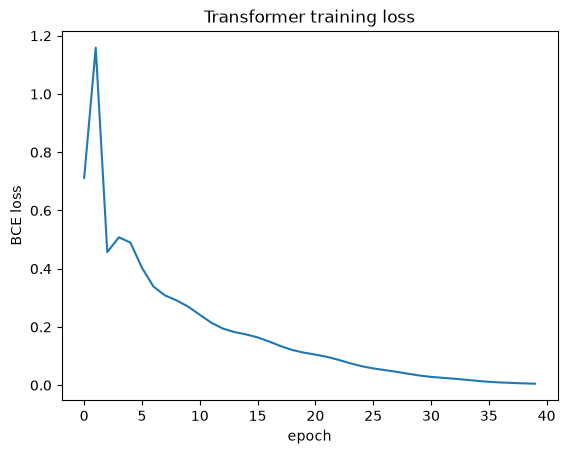

In [5]:
test_preds = model(X_test).numpy().squeeze()
accuracy = np.mean((test_preds >= 0.5) == (y_test >= 0.5))
print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Transformer training loss")
plt.show()